In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 任选其一存在即可
mpl.rcParams['axes.unicode_minus'] = False

In [23]:
def read_2dvector_bin(path):
    with open(path, "rb") as f:
        cols = np.fromfile(f, dtype=np.uint64, count=1)[0]
        rows = np.fromfile(f, dtype=np.uint64, count=1)[0]
        data = np.fromfile(f, dtype=np.float32, count=cols * rows)
    return data.reshape((cols, rows))

giga, de_min, de_max = read_2dvector_bin("imp_de.bin")
giga, re_min, re_max = read_2dvector_bin("imp_re.bin")
df = pd.DataFrame({
    "巨人坐标": giga,
    "平地落点左限": de_min,
    "平地落点右限": de_max,
    "屋顶落点左限": re_min,
    "屋顶落点右限": re_max,
})

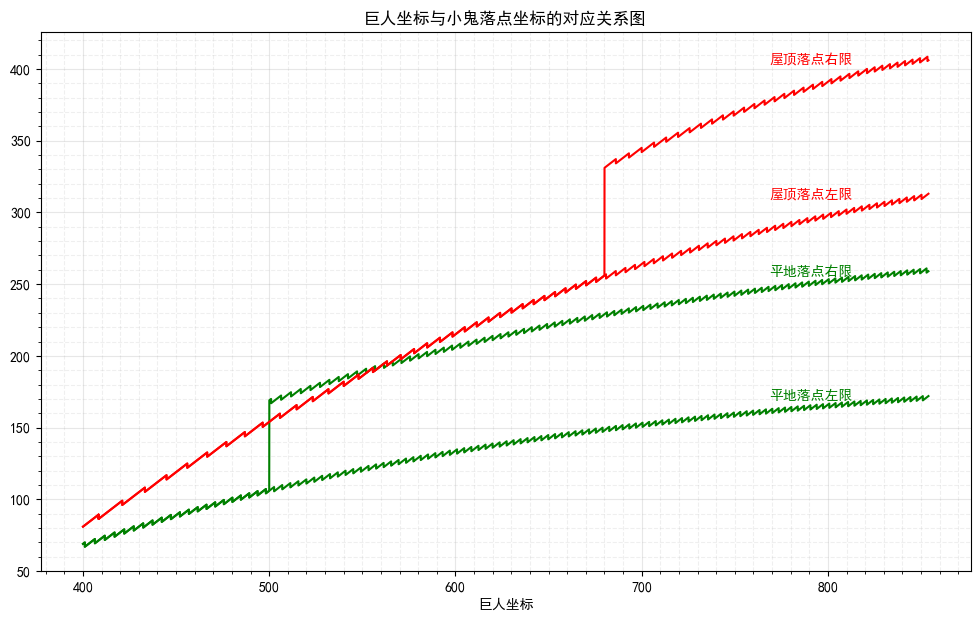

In [27]:
ax = df.plot(x='巨人坐标', y=['平地落点左限', '平地落点右限'], color=['green', 'green'], figsize=(12, 7), legend=False, title="巨人坐标与小鬼落点坐标的对应关系图")
df.plot(x='巨人坐标', y=['屋顶落点左限', '屋顶落点右限'], color=['red', 'red'], legend=False, ax=ax)
for line in ax.get_lines():
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    label = line.get_label()
    ax.text(
        xdata[-1400000], ydata[-1], label, 
        fontsize=10, color=line.get_color(), 
        va='center', ha='left', clip_on=True
    )
import matplotlib.ticker as ticker

ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle='--', alpha=0.2)

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(10))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
plt.show()